In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn requests -q

print("=" * 50)
print("  ✅ All libraries installed successfully!")
print("=" * 50)
print("  • pandas          - data manipulation")
print("  • numpy           - numerical computing")
print("  • matplotlib      - plotting")
print("  • seaborn         - statistical plots")
print("  • scikit-learn    - machine learning")
print("  • imbalanced-learn- SMOTE / resampling")
print("  • requests        - HTTP downloads")
print("=" * 50)

  ✅ All libraries installed successfully!
  • pandas          - data manipulation
  • numpy           - numerical computing
  • matplotlib      - plotting
  • seaborn         - statistical plots
  • scikit-learn    - machine learning
  • imbalanced-learn- SMOTE / resampling
  • requests        - HTTP downloads


In [2]:
 # IMPORT LIBRARIES & GLOBAL SETUP

%matplotlib inline

import os, time, platform, warnings, multiprocessing
multiprocessing.freeze_support()
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import (
    RandomForestClassifier, AdaBoostClassifier,
    HistGradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.naive_bayes      import GaussianNB
from imblearn.over_sampling   import SMOTE
from imblearn.under_sampling  import RandomUnderSampler

# ── Global settings ──────────────────────────────────────────────
NJ      = 1 if platform.system() == "Windows" else -1
PALETTE = ["#2196F3","#F44336","#4CAF50","#FF9800",
           "#9C27B0","#00BCD4","#795548","#607D8B"]
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi":100, "axes.titlesize":12, "axes.labelsize":10})

OUT = "outputs"
os.makedirs(OUT, exist_ok=True)
T0  = time.time()

def tick(msg): print(f"  [{time.time()-T0:5.1f}s]  {msg}")
def savefig(fig, name):
    fig.savefig(os.path.join(OUT, name), bbox_inches="tight", dpi=100)
    plt.show()
    plt.close(fig)
    tick(f"[saved] outputs/{name}")

print("=" * 50)
print("  ✅ All imports successful!")
print(f"  Platform : {platform.system()}")
print(f"  n_jobs   : {NJ}")
print(f"  Output   : ./{OUT}/")
print("=" * 50)

  ✅ All imports successful!
  Platform : Windows
  n_jobs   : 1
  Output   : ./outputs/


In [3]:
# Auto-download the original dataset from Kaggle public mirror
!wget -q https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

# Load dataset
import pandas as pd

df = pd.read_csv("creditcard.csv")

print("Dataset Loaded Successfully:", df.shape)
df.head()

'wget' is not recognized as an internal or external command,
operable program or batch file.


Dataset Loaded Successfully: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# EXPLORATORY DATA ANALYSIS

print("=" * 60)
print("  SECTION 2: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

fraud_n = int(df["Class"].sum())
legit_n = len(df) - fraud_n
fraud_p = fraud_n / len(df) * 100
legit_p = 100 - fraud_p

print(f"\n  CLASS DISTRIBUTION:")
print(f"  {'Legitimate':<20}: {legit_n:,}   ({legit_p:.4f}%)")
print(f"  {'Fraud':<20}: {fraud_n:,}     ({fraud_p:.4f}%)")
print(f"  {'Imbalance Ratio':<20}: 1 fraud per {legit_n//fraud_n} transactions")

print(f"\n  AMOUNT STATISTICS BY CLASS:")
print(df.groupby("Class")["Amount"].describe().round(2))

print(f"\n  TIME STATISTICS:")
print(df[["Time"]].describe().round(2))

print(f"\n  FULL DATASET STATISTICS (Amount & Time):")
print(df[["Time","Amount"]].describe().round(2))

print(f"\n  DATA TYPES:")
print(df.dtypes.to_string())

print(f"\n  MISSING VALUES PER COLUMN:")
print(df.isnull().sum().to_string())

# Working subset for fast EDA
fraud_df = df[df["Class"] == 1]
legit_df = df[df["Class"] == 0].sample(n=50000, random_state=42)
df_fast  = pd.concat([legit_df, fraud_df]).sample(frac=1, random_state=42)

print(f"\n  Working subset: {len(df_fast):,} rows  ({fraud_n} fraud + 50,000 legit)")
print("\n  ✅ EDA Statistics complete!")

  SECTION 2: EXPLORATORY DATA ANALYSIS

  CLASS DISTRIBUTION:
  Legitimate          : 284,315   (99.8273%)
  Fraud               : 492     (0.1727%)
  Imbalance Ratio     : 1 fraud per 577 transactions

  AMOUNT STATISTICS BY CLASS:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87

  TIME STATISTICS:
            Time
count  284807.00
mean    94813.86
std     47488.15
min         0.00
25%     54201.50
50%     84692.00
75%    139320.50
max    172792.00

  FULL DATASET STATISTICS (Amount & Time):
            Time     Amount
count  284807.00  284807.00
mean    94813.86      88.35
std     47488.15     250.12
min         0.00       0.00
25%     54201.50       5.60
50%     84692.00      22.00
75%    139320.50      77.16
max    172792.00   25691.16

  DATA TYPES:
Time      f

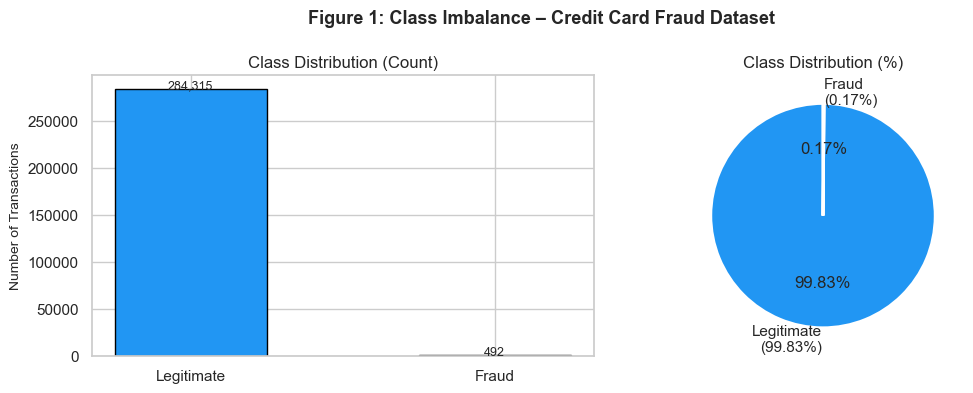

  [ 34.0s]  [saved] outputs/fig01_class_distribution.png


In [5]:
# FIGURE 1 – CLASS DISTRIBUTION (Bar + Pie)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(["Legitimate","Fraud"], [legit_n, fraud_n],
            color=["#2196F3","#F44336"], edgecolor="black", width=0.5)
axes[0].set_title("Class Distribution (Count)")
axes[0].set_ylabel("Number of Transactions")
for bar, val in zip(axes[0].patches, [legit_n, fraud_n]):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+500, f"{val:,}", ha="center", fontsize=9)

# Pie chart
axes[1].pie([legit_p, fraud_p],
            labels=["Legitimate\n(99.83%)","Fraud\n(0.17%)"],
            colors=["#2196F3","#F44336"], autopct="%1.2f%%",
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Class Distribution (%)")

fig.suptitle("Figure 1: Class Imbalance – Credit Card Fraud Dataset",
             fontsize=13, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig01_class_distribution.png")

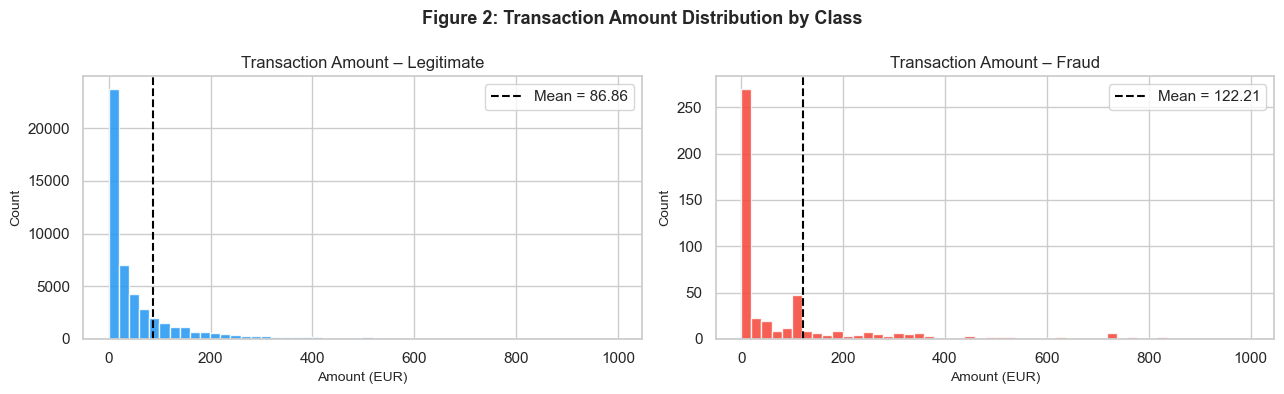

  [ 39.5s]  [saved] outputs/fig02_amount_distribution.png


In [6]:
# FIGURE 2 – TRANSACTION AMOUNT BY CLASS


fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, (cls, label, color) in enumerate([(0,"Legitimate","#2196F3"),(1,"Fraud","#F44336")]):
    s = df_fast[df_fast["Class"]==cls]["Amount"]
    axes[i].hist(s[s<1000], bins=50, color=color, edgecolor="white", alpha=0.85)
    axes[i].set_title(f"Transaction Amount – {label}")
    axes[i].set_xlabel("Amount (EUR)")
    axes[i].set_ylabel("Count")
    axes[i].axvline(s.mean(), color="black", ls="--",
                    label=f"Mean = {s.mean():.2f}")
    axes[i].legend()

fig.suptitle("Figure 2: Transaction Amount Distribution by Class",
             fontsize=13, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig02_amount_distribution.png")

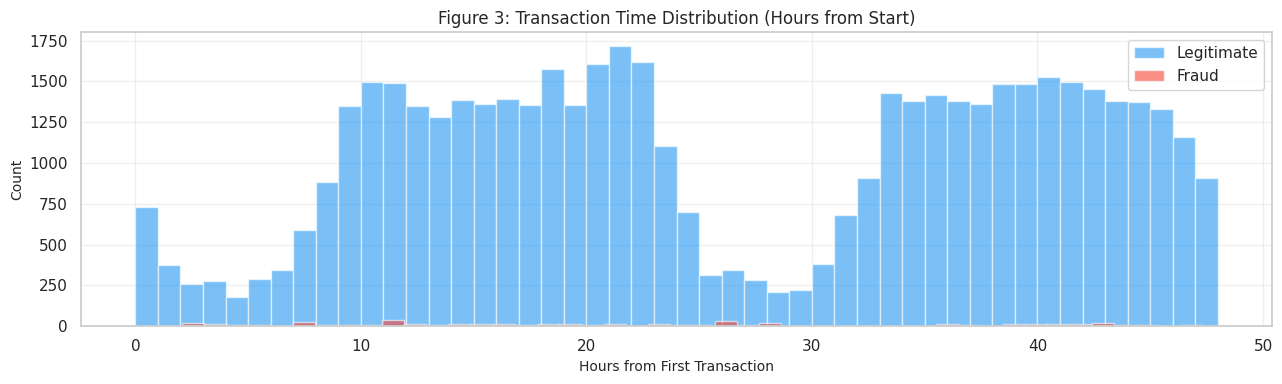

  [1446.9s]  [saved] outputs/fig03_time_distribution.png


In [13]:
# FIGURE 3 – TRANSACTION TIME DISTRIBUTION


fig, ax = plt.subplots(figsize=(13, 4))
for cls, label, color in [(0,"Legitimate","#2196F3"),(1,"Fraud","#F44336")]:
    ax.hist(df_fast[df_fast["Class"]==cls]["Time"]/3600,
            bins=48, alpha=0.6, label=label, color=color)

ax.set_title("Figure 3: Transaction Time Distribution (Hours from Start)")
ax.set_xlabel("Hours from First Transaction")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
savefig(fig, "fig03_time_distribution.png")

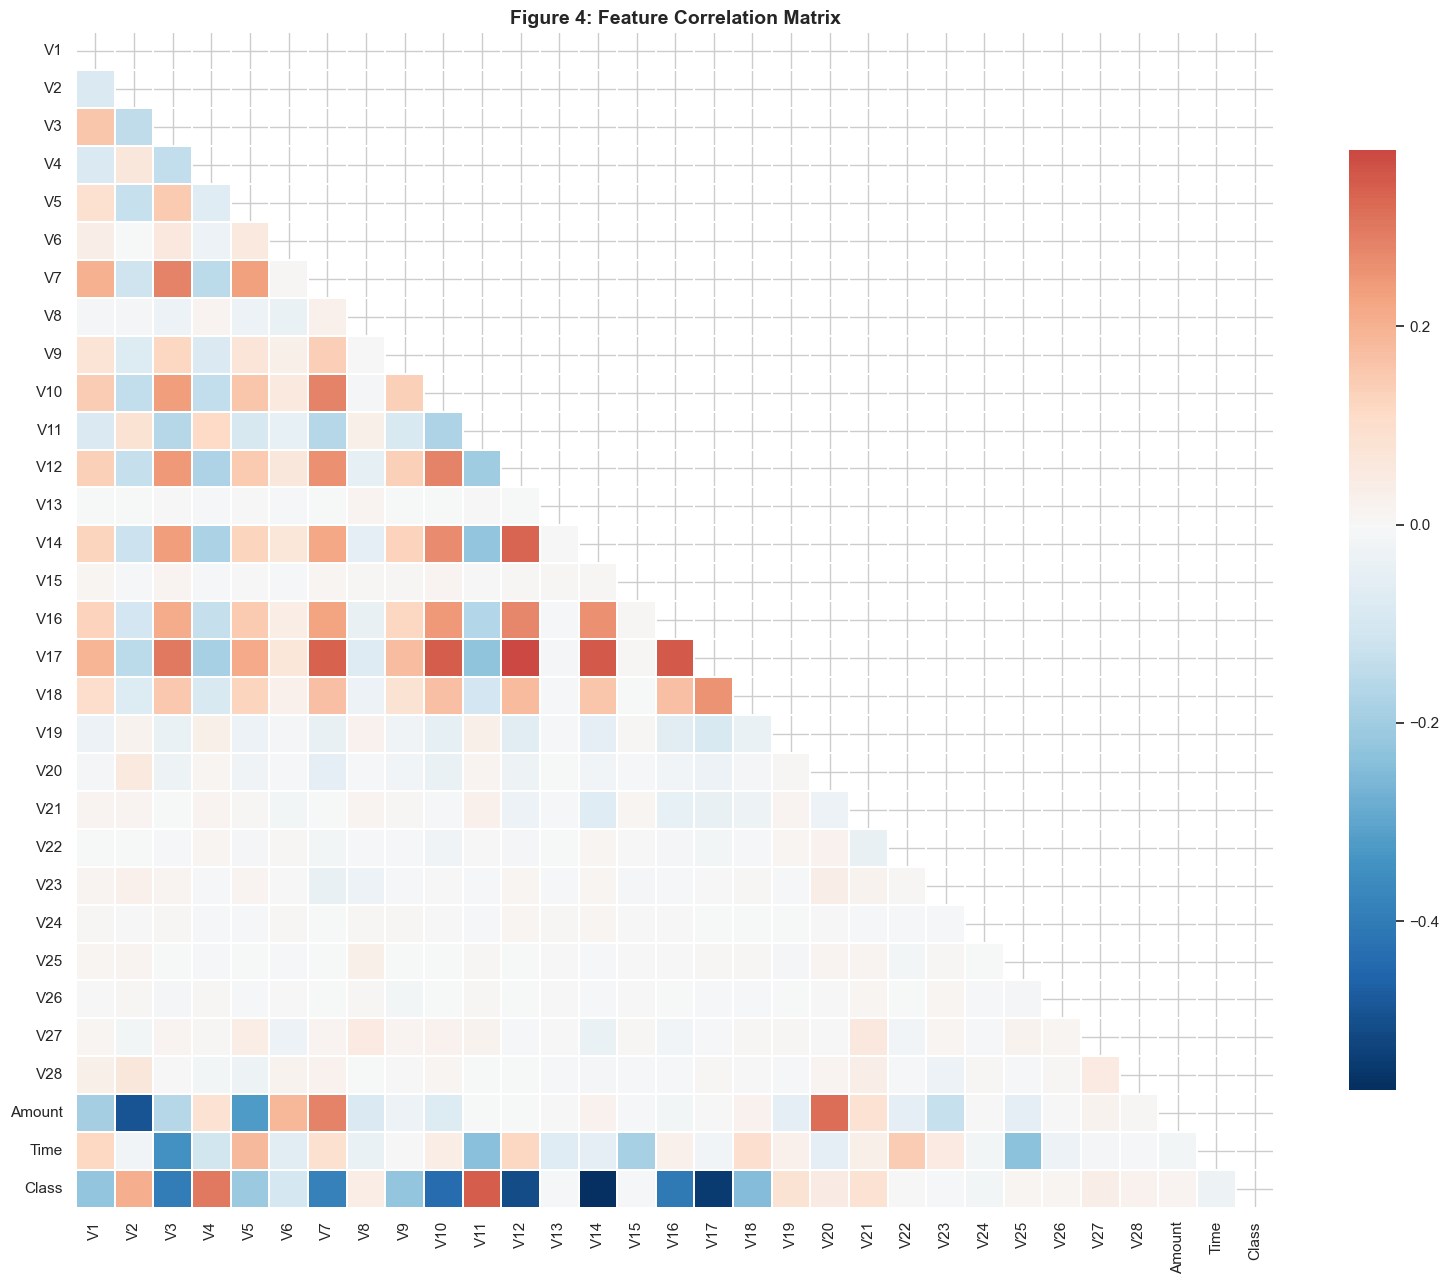

  [ 48.1s]  [saved] outputs/fig04_correlation_heatmap.png


In [7]:
# FIGURE 4 – CORRELATION HEATMAP

pca_cols   = [c for c in df.columns if c.startswith("V")]
class_corr = df_fast.corr()["Class"].drop("Class").sort_values()

corr = df_fast[pca_cols + ["Amount","Time","Class"]].corr()
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr,
            mask=np.triu(np.ones_like(corr, dtype=bool)),
            ax=ax, cmap="RdBu_r", center=0,
            linewidths=0.3, cbar_kws={"shrink":0.8})
ax.set_title("Figure 4: Feature Correlation Matrix",
             fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig04_correlation_heatmap.png")

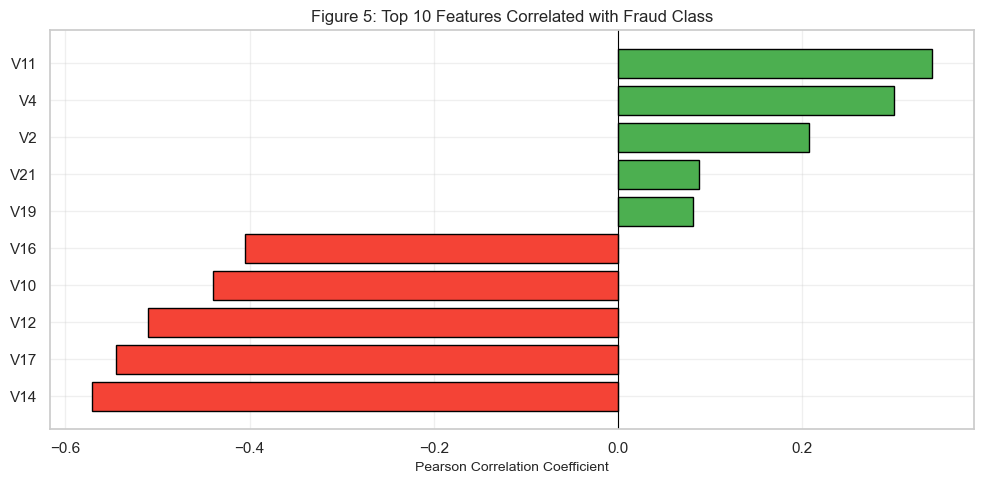

  [ 55.5s]  [saved] outputs/fig05_feature_correlation.png
Top 5 negative correlations (most indicative of fraud):
V14   -0.5707
V17   -0.5450
V12   -0.5101
V10   -0.4399
V16   -0.4048

Top 5 positive correlations:
V19    0.0810
V21    0.0885
V2     0.2074
V4     0.3001
V11    0.3411


In [8]:
# FIGURE 5 – TOP 10 FEATURES CORRELATED WITH FRAUD


top_feats = pd.concat([class_corr.head(5), class_corr.tail(5)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_feats.index, top_feats.values,
        color=["#F44336" if v<0 else "#4CAF50" for v in top_feats.values],
        edgecolor="black")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Figure 5: Top 10 Features Correlated with Fraud Class")
ax.set_xlabel("Pearson Correlation Coefficient")
ax.grid(True, alpha=0.3)
fig.tight_layout()
savefig(fig, "fig05_feature_correlation.png")

print("Top 5 negative correlations (most indicative of fraud):")
print(class_corr.head(5).round(4).to_string())
print("\nTop 5 positive correlations:")
print(class_corr.tail(5).round(4).to_string())

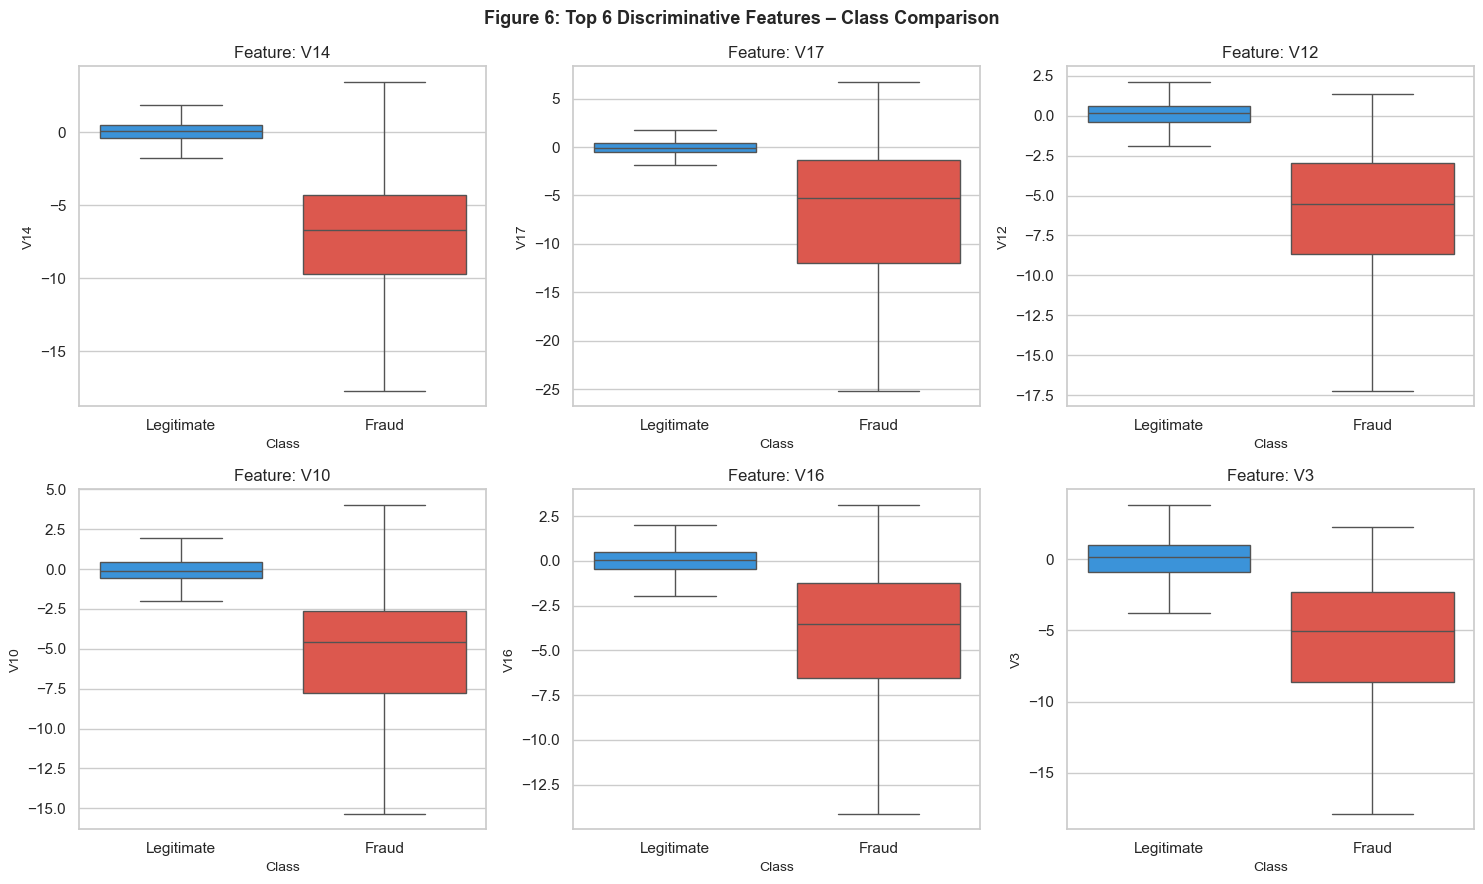

  [ 67.8s]  [saved] outputs/fig06_boxplots_top_features.png


In [9]:
# FIGURE 6 – BOXPLOTS OF TOP FEATURES


top6 = class_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, feat in zip(axes.flatten(), top6):
    sns.boxplot(data=df_fast, x="Class", y=feat, ax=ax,
                palette=["#2196F3","#F44336"], showfliers=False)
    ax.set_xticklabels(["Legitimate","Fraud"])
    ax.set_title(f"Feature: {feat}")

fig.suptitle("Figure 6: Top 6 Discriminative Features – Class Comparison",
             fontsize=13, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig06_boxplots_top_features.png")

  SECTION 3: PREPROCESSING & RESAMPLING

  Train set : 40,393 samples  |  Fraud: 394
  Test set  : 10,099  samples  |  Fraud: 98

  Original   : {np.int64(0): np.int64(39999), np.int64(1): np.int64(394)}
  SMOTE      : {np.int64(0): np.int64(39999), np.int64(1): np.int64(39999)}
  UnderSamp  : {np.int64(0): np.int64(788), np.int64(1): np.int64(394)}


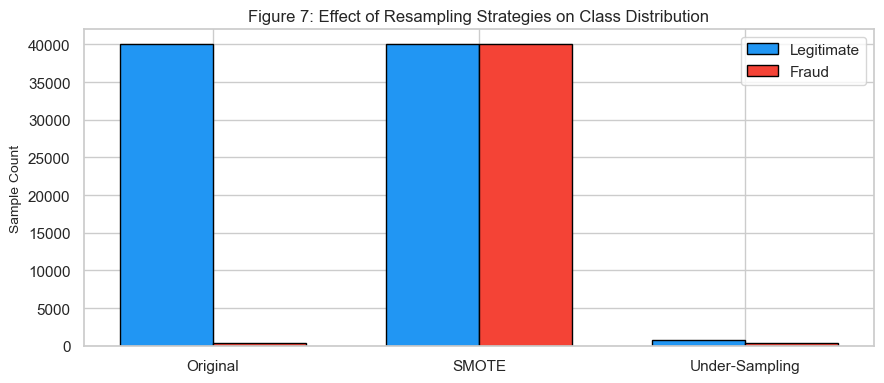

  [ 79.3s]  [saved] outputs/fig07_resampling_comparison.png

  ✅ Preprocessing complete!


In [10]:
# PREPROCESSING & RESAMPLING


print("=" * 55)
print("  SECTION 3: PREPROCESSING & RESAMPLING")
print("=" * 55)

# Scale Amount and Time
sc = StandardScaler()
df_fast2 = df_fast.copy()
df_fast2["scaled_Amount"] = sc.fit_transform(df_fast2[["Amount"]])
df_fast2["scaled_Time"]   = sc.fit_transform(df_fast2[["Time"]])
df_fast2 = df_fast2.drop(columns=["Amount","Time"])

X = df_fast2.drop(columns=["Class"])
y = df_fast2["Class"]

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n  Train set : {X_train.shape[0]:,} samples  |  Fraud: {y_train.sum()}")
print(f"  Test set  : {X_test.shape[0]:,}  samples  |  Fraud: {y_test.sum()}")

# SMOTE
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

# Under-sampling
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_us, y_us = under.fit_resample(X_train, y_train)

print(f"\n  Original   : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"  SMOTE      : {dict(zip(*np.unique(y_sm,    return_counts=True)))}")
print(f"  UnderSamp  : {dict(zip(*np.unique(y_us,    return_counts=True)))}")

# Figure 7 – Resampling comparison
fig, ax = plt.subplots(figsize=(9, 4))
cats = ["Original","SMOTE","Under-Sampling"]
lc = [(y_train==0).sum(),(y_sm==0).sum(),(y_us==0).sum()]
fc = [(y_train==1).sum(),(y_sm==1).sum(),(y_us==1).sum()]
xp = np.arange(3); w = 0.35
ax.bar(xp-w/2, lc, w, label="Legitimate", color="#2196F3", edgecolor="black")
ax.bar(xp+w/2, fc, w, label="Fraud",      color="#F44336", edgecolor="black")
ax.set_xticks(xp); ax.set_xticklabels(cats)
ax.set_ylabel("Sample Count"); ax.legend()
ax.set_title("Figure 7: Effect of Resampling Strategies on Class Distribution")
fig.tight_layout()
savefig(fig, "fig07_resampling_comparison.png")

print("\n  ✅ Preprocessing complete!")

In [11]:
# TRAIN ALL 14 MODELS


print("=" * 60)
print("  SECTION 4: MODEL TRAINING & EVALUATION")
print("=" * 60)

def run_model(name, clf, Xtr, ytr, resamp):
    t0 = time.time()
    clf.fit(Xtr, ytr)
    elapsed = time.time() - t0
    yp   = clf.predict(X_test)
    prob = clf.predict_proba(X_test)[:,1] if hasattr(clf,"predict_proba") else None
    row  = {
        "Model"     : name,
        "Resampling": resamp,
        "Accuracy"  : accuracy_score(y_test, yp),
        "Precision" : precision_score(y_test, yp, zero_division=0),
        "Recall"    : recall_score(y_test, yp, zero_division=0),
        "F1"        : f1_score(y_test, yp, zero_division=0),
        "ROC-AUC"   : roc_auc_score(y_test, prob) if prob is not None else float("nan"),
        "PR-AUC"    : average_precision_score(y_test, prob) if prob is not None else float("nan"),
        "Time_s"    : round(elapsed, 2),
    }
    tick(f"{name:<36}  F1={row['F1']:.4f}  AUC={row['ROC-AUC']:.4f}  [{elapsed:.1f}s]")
    return clf, row, prob

results=[]; models={}; probs={}
def add(name, clf, Xtr, ytr, resamp):
    m, row, prob = run_model(name, clf, Xtr, ytr, resamp)
    results.append(row); models[name]=m; probs[name]=prob

print("\n  [A] Baseline – no resampling")
add("Logistic Regression", LogisticRegression(max_iter=300,random_state=42),                              X_train,y_train,"None")
add("Decision Tree",        DecisionTreeClassifier(max_depth=6,random_state=42),                           X_train,y_train,"None")
add("Random Forest",        RandomForestClassifier(n_estimators=30,random_state=42,n_jobs=NJ),             X_train,y_train,"None")
add("Extra Trees",          ExtraTreesClassifier(n_estimators=30,random_state=42,n_jobs=NJ),               X_train,y_train,"None")
add("HistGradBoost",        HistGradientBoostingClassifier(max_iter=50,random_state=42),                   X_train,y_train,"None")
add("AdaBoost",             AdaBoostClassifier(n_estimators=30,random_state=42),                           X_train,y_train,"None")
add("Naive Bayes",          GaussianNB(),                                                                   X_train,y_train,"None")

print("\n  [B] SMOTE oversampling")
add("LR + SMOTE",  LogisticRegression(max_iter=300,random_state=42),                               X_sm,y_sm,"SMOTE")
add("RF + SMOTE",  RandomForestClassifier(n_estimators=30,random_state=42,n_jobs=NJ),              X_sm,y_sm,"SMOTE")
add("HGB + SMOTE", HistGradientBoostingClassifier(max_iter=50,random_state=42),                    X_sm,y_sm,"SMOTE")

print("\n  [C] Under-sampling")
add("RF + UnderSample",  RandomForestClassifier(n_estimators=30,random_state=42,n_jobs=NJ),        X_us,y_us,"UnderSample")
add("HGB + UnderSample", HistGradientBoostingClassifier(max_iter=50,random_state=42),              X_us,y_us,"UnderSample")

print("\n  [D] Cost-sensitive (balanced class weights)")
add("LR (balanced)", LogisticRegression(class_weight="balanced",max_iter=300,random_state=42),     X_train,y_train,"Class-Weight")
add("RF (balanced)", RandomForestClassifier(n_estimators=30,class_weight="balanced",
                     random_state=42,n_jobs=NJ),                                                   X_train,y_train,"Class-Weight")

df_res = pd.DataFrame(results).sort_values("F1",ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("  ALL MODEL RESULTS (sorted by F1)")
print("="*60)
print(df_res[["Model","Resampling","Precision","Recall","F1","ROC-AUC","PR-AUC"]].to_string(index=False))
print("\n  ✅ All models trained!")

  SECTION 4: MODEL TRAINING & EVALUATION

  [A] Baseline – no resampling
  [ 86.9s]  Logistic Regression                   F1=0.8539  AUC=0.9801  [0.2s]
  [ 89.8s]  Decision Tree                         F1=0.8556  AUC=0.8997  [2.9s]
  [115.8s]  Random Forest                         F1=0.9071  AUC=0.9465  [25.9s]
  [117.7s]  Extra Trees                           F1=0.8989  AUC=0.9611  [1.7s]
  [118.9s]  HistGradBoost                         F1=0.8770  AUC=0.9829  [1.0s]
  [136.0s]  AdaBoost                              F1=0.8249  AUC=0.9759  [17.0s]
  [136.2s]  Naive Bayes                           F1=0.3904  AUC=0.9638  [0.1s]

  [B] SMOTE oversampling
  [136.7s]  LR + SMOTE                            F1=0.4000  AUC=0.9824  [0.5s]
  [172.7s]  RF + SMOTE                            F1=0.8677  AUC=0.9780  [35.8s]
  [174.7s]  HGB + SMOTE                           F1=0.7748  AUC=0.9838  [1.8s]

  [C] Under-sampling
  [175.2s]  RF + UnderSample                      F1=0.5285  AUC=0.9760  [0.

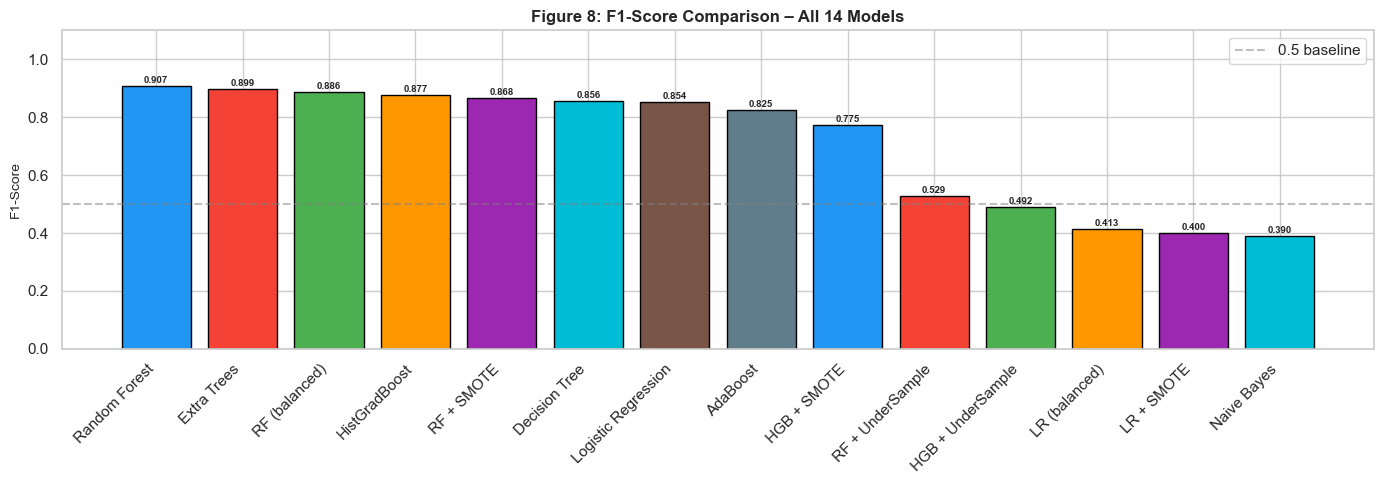

  [192.2s]  [saved] outputs/fig08_f1_comparison.png


In [12]:
# FIGURE 8 – F1-SCORE BAR CHART ALL MODELS


fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(df_res["Model"], df_res["F1"],
              color=[PALETTE[i%len(PALETTE)] for i in range(len(df_res))],
              edgecolor="black")
ax.set_ylim(0, 1.10)
ax.set_ylabel("F1-Score")
ax.set_title("Figure 8: F1-Score Comparison – All 14 Models", fontweight="bold")
ax.set_xticklabels(df_res["Model"], rotation=45, ha="right")
for bar, val in zip(bars, df_res["F1"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.3f}", ha="center", fontsize=7, fontweight="bold")
ax.axhline(0.5, color="gray", ls="--", alpha=0.5, label="0.5 baseline")
ax.legend()
fig.tight_layout()
savefig(fig, "fig08_f1_comparison.png")

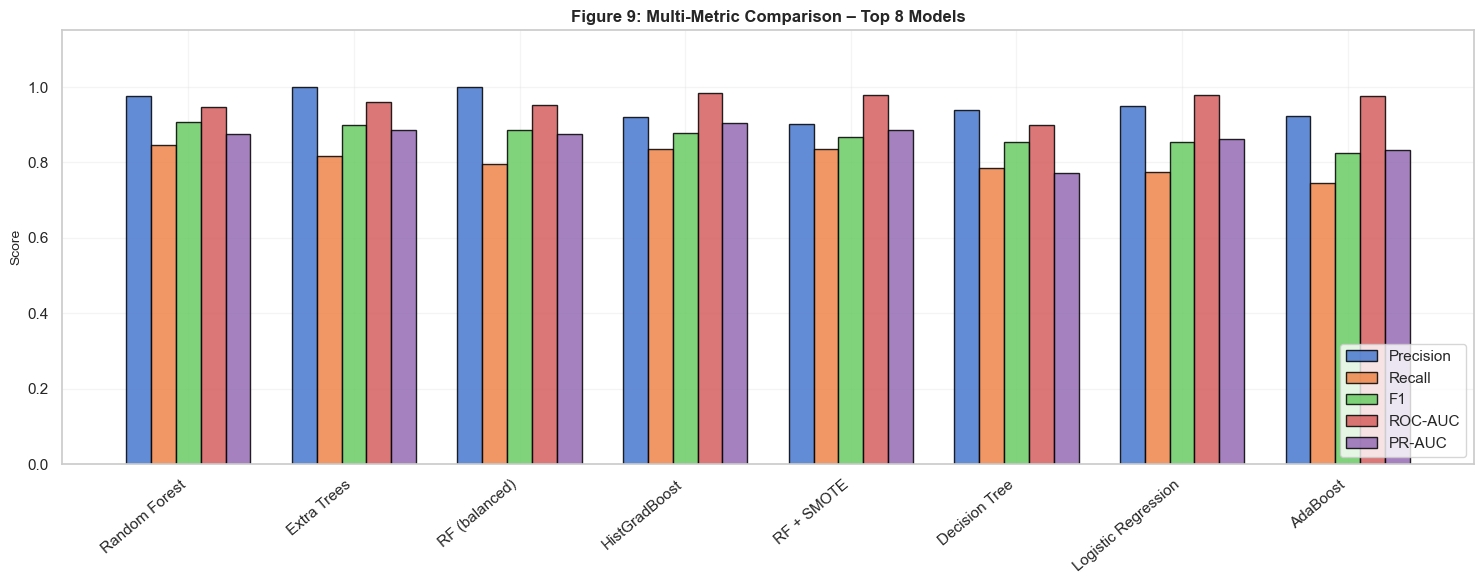

  [266.0s]  [saved] outputs/fig09_multi_metric_top8.png


In [13]:
 # FIGURE 9 – MULTI-METRIC COMPARISON TOP 8 MODELS


top8 = df_res.head(8)
xp   = np.arange(len(top8))
w    = 0.15

fig, ax = plt.subplots(figsize=(15, 6))
for i, metric in enumerate(["Precision","Recall","F1","ROC-AUC","PR-AUC"]):
    ax.bar(xp+i*w, top8[metric], w, label=metric, edgecolor="black", alpha=0.85)

ax.set_xticks(xp+w*2)
ax.set_xticklabels(top8["Model"], rotation=40, ha="right")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Figure 9: Multi-Metric Comparison – Top 8 Models", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.2)
fig.tight_layout()
savefig(fig, "fig09_multi_metric_top8.png")

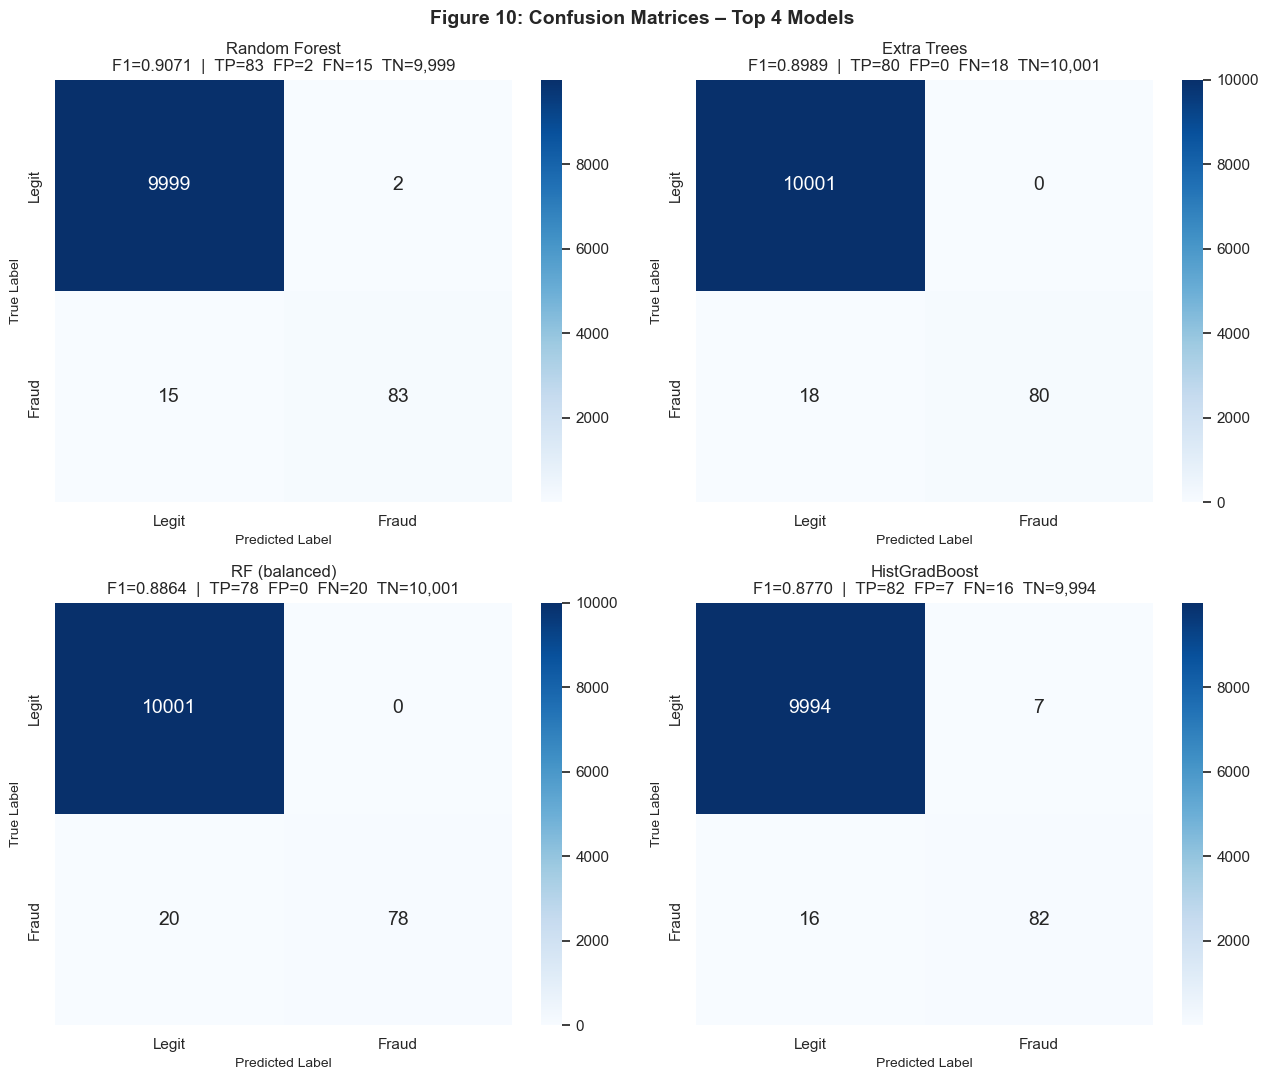

  [280.9s]  [saved] outputs/fig10_confusion_matrices.png


In [14]:
 # FIGURE 10 – CONFUSION MATRICES TOP 4 MODELS


fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, mname in zip(axes.flatten(), df_res.head(4)["Model"].tolist()):
    yp = models[mname].predict(X_test)
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit","Fraud"],
                yticklabels=["Legit","Fraud"],
                annot_kws={"size":14})
    f1 = f1_score(y_test, yp)
    tn,fp,fn,tp = cm.ravel()
    ax.set_title(f"{mname}\nF1={f1:.4f}  |  TP={tp}  FP={fp}  FN={fn}  TN={tn:,}")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

fig.suptitle("Figure 10: Confusion Matrices – Top 4 Models",
             fontsize=14, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig10_confusion_matrices.png")

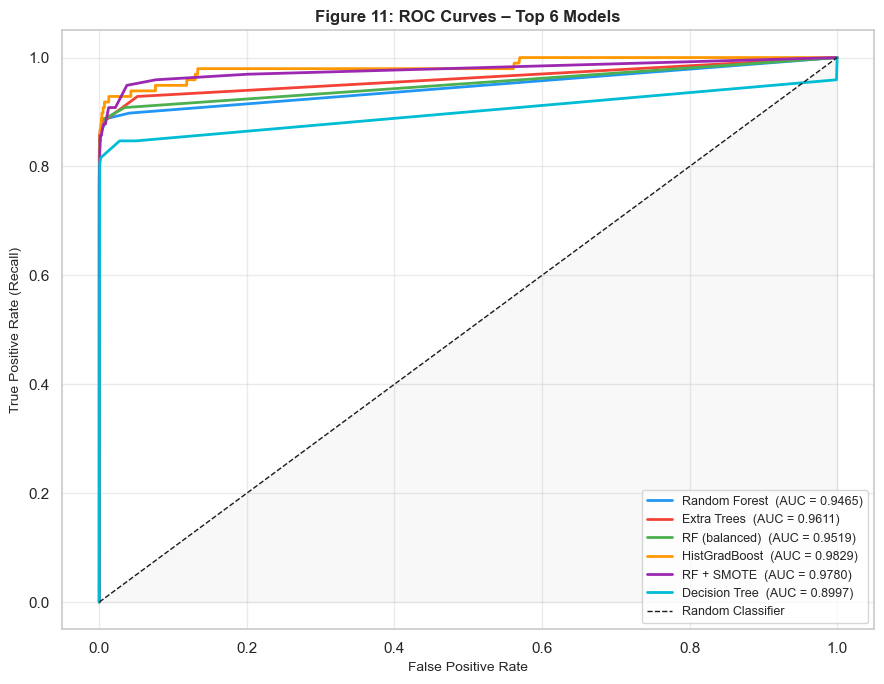

  [292.8s]  [saved] outputs/fig11_roc_curves.png


In [15]:
# FIGURE 11 – ROC CURVES TOP 6 MODELS


fig, ax = plt.subplots(figsize=(9, 7))
for i, (_, row) in enumerate(df_res.dropna(subset=["ROC-AUC"]).head(6).iterrows()):
    p = probs.get(row["Model"])
    if p is not None:
        fpr, tpr, _ = roc_curve(y_test, p)
        ax.plot(fpr, tpr, lw=2, color=PALETTE[i%len(PALETTE)],
                label=f"{row['Model']}  (AUC = {row['ROC-AUC']:.4f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Random Classifier")
ax.fill_between([0,1],[0,1], alpha=0.05, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("Figure 11: ROC Curves – Top 6 Models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.4)
fig.tight_layout()
savefig(fig, "fig11_roc_curves.png")

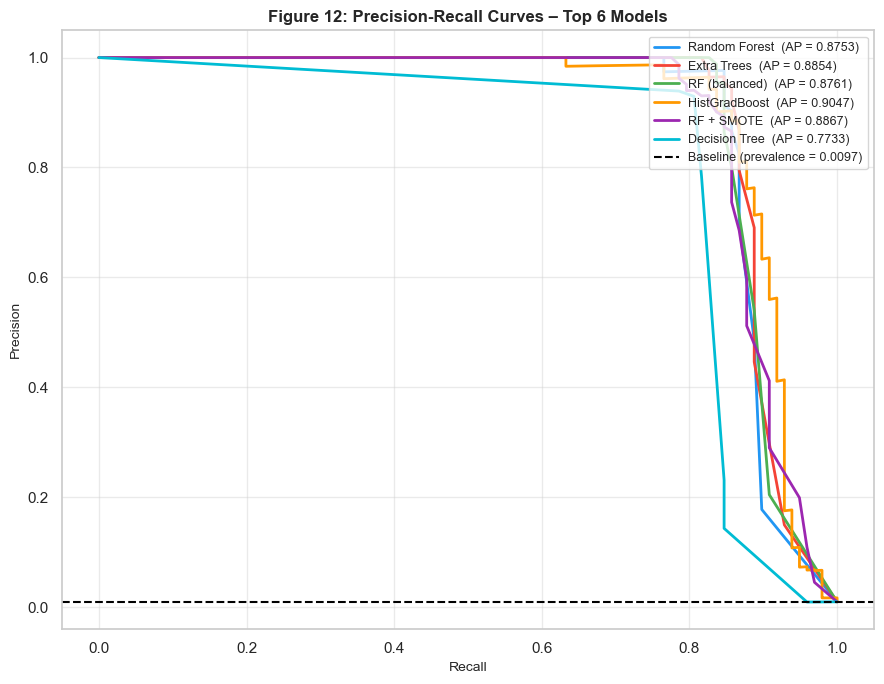

  [306.0s]  [saved] outputs/fig12_precision_recall_curves.png


In [16]:
# FIGURE 12 – PRECISION-RECALL CURVES


fig, ax = plt.subplots(figsize=(9, 7))
for i, (_, row) in enumerate(df_res.dropna(subset=["PR-AUC"]).head(6).iterrows()):
    p = probs.get(row["Model"])
    if p is not None:
        pc, rc, _ = precision_recall_curve(y_test, p)
        ap = average_precision_score(y_test, p)
        ax.plot(rc, pc, lw=2, color=PALETTE[i%len(PALETTE)],
                label=f"{row['Model']}  (AP = {ap:.4f})")

ax.axhline(y_test.mean(), color="black", ls="--",
           label=f"Baseline (prevalence = {y_test.mean():.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Figure 12: Precision-Recall Curves – Top 6 Models", fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.4)
fig.tight_layout()
savefig(fig, "fig12_precision_recall_curves.png")

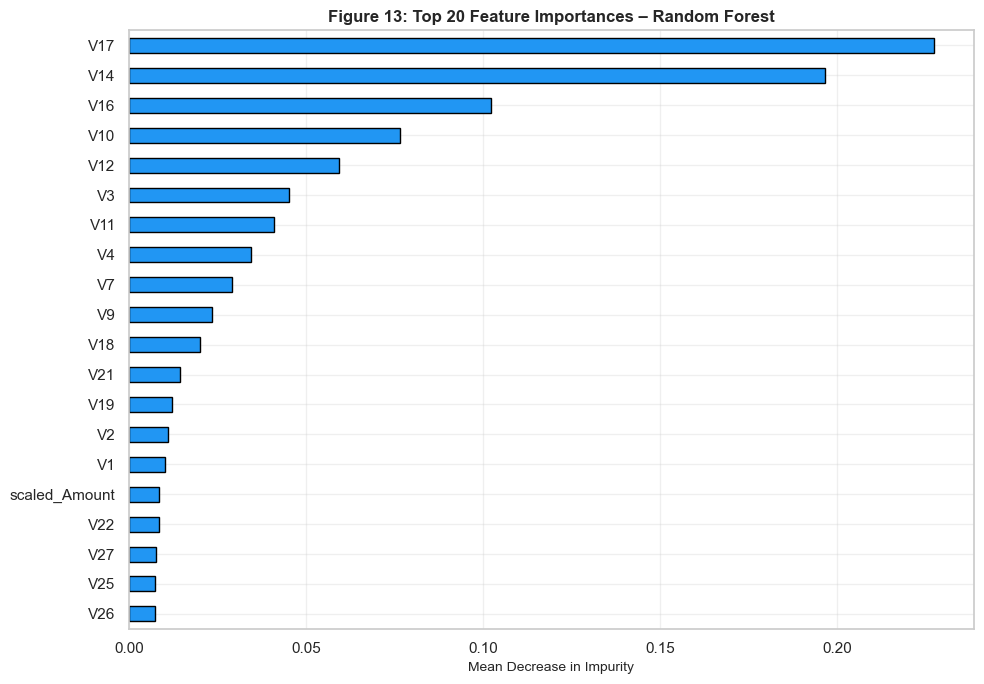

  [315.3s]  [saved] outputs/fig13_feature_importance_rf.png
Top 10 features by importance (Random Forest):
V17    0.22735
V14    0.19661
V16    0.10234
V10    0.07648
V12    0.05940
V3     0.04524
V11    0.04110
V4     0.03443
V7     0.02925
V9     0.02343


In [17]:
# FIGURE 13 – RANDOM FOREST FEATURE IMPORTANCE


rf  = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X.columns)
imp = imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
imp.plot.barh(ax=ax, color="#2196F3", edgecolor="black")
ax.invert_yaxis()
ax.set_title("Figure 13: Top 20 Feature Importances – Random Forest",
             fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity")
ax.grid(True, alpha=0.3)
fig.tight_layout()
savefig(fig, "fig13_feature_importance_rf.png")

print("Top 10 features by importance (Random Forest):")
print(imp.head(10).round(5).to_string())

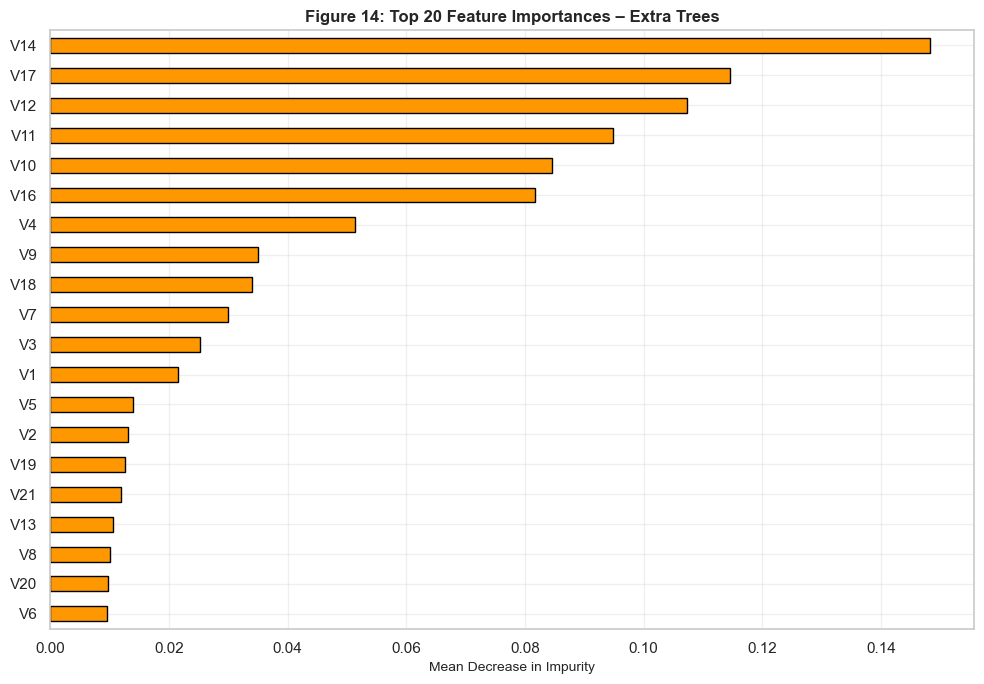

  [352.5s]  [saved] outputs/fig14_feature_importance_et.png
Top 10 features by importance (Extra Trees):
V14    0.14827
V17    0.11464
V12    0.10730
V11    0.09477
V10    0.08449
V16    0.08164
V4     0.05139
V9     0.03492
V18    0.03398
V7     0.03001


In [19]:
# FIGURE 14 – EXTRA TREES FEATURE IMPORTANCE


et     = models["Extra Trees"]
imp_et = pd.Series(et.feature_importances_, index=X.columns)
imp_et = imp_et.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
imp_et.plot.barh(ax=ax, color="#FF9800", edgecolor="black")
ax.invert_yaxis()
ax.set_title("Figure 14: Top 20 Feature Importances – Extra Trees",
             fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity")
ax.grid(True, alpha=0.3)
fig.tight_layout()
savefig(fig, "fig14_feature_importance_et.png")

print("Top 10 features by importance (Extra Trees):")
print(imp_et.head(10).round(5).to_string())

In [20]:
 # BEST MODEL DETAILED REPORT


best_name = df_res.iloc[0]["Model"]
best_row  = df_res.iloc[0]

print("=" * 60)
print(f"  BEST MODEL BY F1-SCORE: {best_name}")
print("=" * 60)
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  F1-Score  : {best_row['F1']:.4f}")
print(f"  ROC-AUC   : {best_row['ROC-AUC']:.4f}")
print(f"  PR-AUC    : {best_row['PR-AUC']:.4f}")
print(f"  Resampling: {best_row['Resampling']}")
print(f"  Train time: {best_row['Time_s']} seconds")

yp_best = models[best_name].predict(X_test)
print("\n  Full Classification Report:")
print(classification_report(y_test, yp_best, target_names=["Legitimate","Fraud"]))

tn, fp, fn, tp = confusion_matrix(y_test, yp_best).ravel()
print(f"  Confusion Matrix:")
print(f"  TN = {tn:,}  |  FP = {fp:,}")
print(f"  FN = {fn:,}  |  TP = {tp:,}")
print(f"\n  Fraud missed      : {fn} cases  ({fn/(fn+tp)*100:.1f}%)")
print(f"  False alert rate  : {fp/(fp+tn)*100:.4f}%  ({fp} legit blocked)")

  BEST MODEL BY F1-SCORE: Random Forest
  Precision : 0.9765
  Recall    : 0.8469
  F1-Score  : 0.9071
  ROC-AUC   : 0.9465
  PR-AUC    : 0.8753
  Resampling: None
  Train time: 25.87 seconds

  Full Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     10001
       Fraud       0.98      0.85      0.91        98

    accuracy                           1.00     10099
   macro avg       0.99      0.92      0.95     10099
weighted avg       1.00      1.00      1.00     10099

  Confusion Matrix:
  TN = 9,999  |  FP = 2
  FN = 15  |  TP = 83

  Fraud missed      : 15 cases  (15.3%)
  False alert rate  : 0.0200%  (2 legit blocked)


  Model                           F1 Mean   F1 Std   AUC Mean
  ----------------------------------------------------------
  Logistic Regression              0.8729   0.0030     0.9791
  Random Forest                    0.8901   0.0028     0.9458
  HistGradBoost                    0.8755   0.0266     0.9716
  Extra Trees                      0.8812   0.0121     0.9468


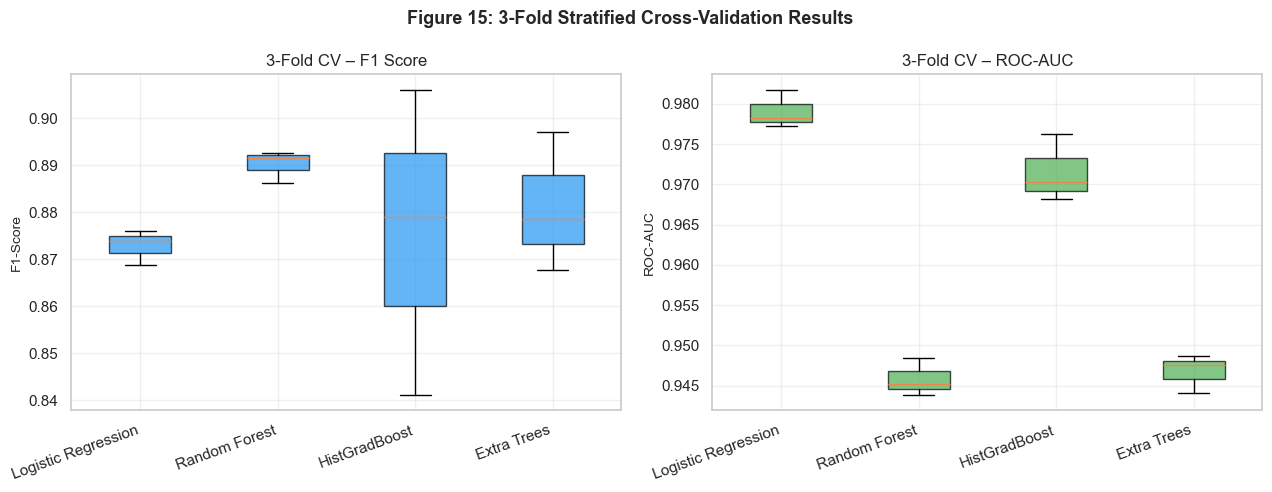

  [437.5s]  [saved] outputs/fig15_cross_validation.png


In [21]:
 # FIGURE 15 – 3-FOLD CROSS-VALIDATION


cv_clfs = {
    "Logistic Regression": LogisticRegression(max_iter=300, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=20, random_state=42, n_jobs=NJ),
    "HistGradBoost"      : HistGradientBoostingClassifier(max_iter=30, random_state=42),
    "Extra Trees"        : ExtraTreesClassifier(n_estimators=20, random_state=42, n_jobs=NJ),
}
skf    = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_res = {}

print(f"  {'Model':<28} {'F1 Mean':>10} {'F1 Std':>8} {'AUC Mean':>10}")
print("  " + "-"*58)
for mname, clf in cv_clfs.items():
    f1s  = cross_val_score(clf, X_train, y_train, cv=skf, scoring="f1",      n_jobs=NJ)
    aucs = cross_val_score(clf, X_train, y_train, cv=skf, scoring="roc_auc", n_jobs=NJ)
    cv_res[mname] = {"F1":f1s, "AUC":aucs}
    print(f"  {mname:<28} {f1s.mean():>10.4f} {f1s.std():>8.4f} {aucs.mean():>10.4f}")

labels = list(cv_res.keys())
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].boxplot([cv_res[m]["F1"]  for m in labels], labels=labels,
                patch_artist=True, boxprops=dict(facecolor="#2196F3", alpha=0.7))
axes[0].set_title("3-Fold CV – F1 Score")
axes[0].set_ylabel("F1-Score")
axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([cv_res[m]["AUC"] for m in labels], labels=labels,
                patch_artist=True, boxprops=dict(facecolor="#4CAF50", alpha=0.7))
axes[1].set_title("3-Fold CV – ROC-AUC")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_xticklabels(labels, rotation=20, ha="right")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Figure 15: 3-Fold Stratified Cross-Validation Results",
             fontsize=13, fontweight="bold")
fig.tight_layout()
savefig(fig, "fig15_cross_validation.png")

  Model analysed    : Random Forest
  Optimal threshold : 0.35  (maximises F1)

 Threshold  Precision   Recall       F1
      0.05   0.486034 0.887755 0.628159
      0.10   0.696721 0.867347 0.772727
      0.15   0.865979 0.857143 0.861538
      0.20   0.884211 0.857143 0.870466
      0.25   0.912088 0.846939 0.878307
      0.30   0.922222 0.846939 0.882979
      0.35   0.976471 0.846939 0.907104
      0.40   0.976471 0.846939 0.907104
      0.45   0.976471 0.846939 0.907104
      0.50   0.976471 0.846939 0.907104
      0.55   0.976190 0.836735 0.901099
      0.60   0.975309 0.806122 0.882682
      0.65   0.974026 0.765306 0.857143
      0.70   1.000000 0.765306 0.867052
      0.75   1.000000 0.744898 0.853801
      0.80   1.000000 0.734694 0.847059
      0.85   1.000000 0.642857 0.782609
      0.90   1.000000 0.571429 0.727273
      0.95   1.000000 0.540816 0.701987


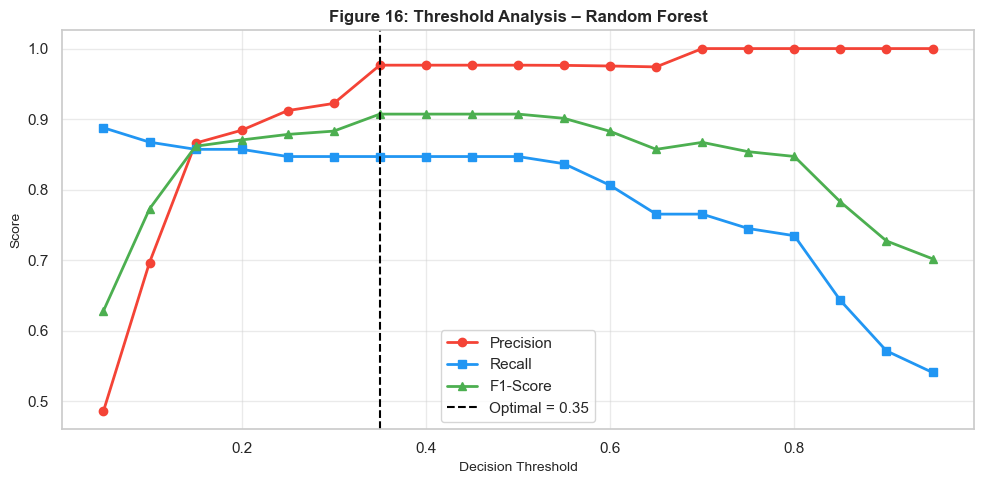

  [438.8s]  [saved] outputs/fig16_threshold_analysis.png


In [22]:
 # FIGURE 16 – THRESHOLD ANALYSIS


best_prob_name = df_res.dropna(subset=["ROC-AUC"]).iloc[0]["Model"]
bp             = probs.get(best_prob_name)

if bp is not None:
    th_rows = []
    for th in np.arange(0.05, 0.96, 0.05):
        yp_th = (bp >= th).astype(int)
        th_rows.append({
            "Threshold": round(float(th), 2),
            "Precision": precision_score(y_test, yp_th, zero_division=0),
            "Recall"   : recall_score(y_test, yp_th, zero_division=0),
            "F1"       : f1_score(y_test, yp_th, zero_division=0),
        })
    df_th    = pd.DataFrame(th_rows)
    best_th  = df_th.loc[df_th["F1"].idxmax(), "Threshold"]

    print(f"  Model analysed    : {best_prob_name}")
    print(f"  Optimal threshold : {best_th:.2f}  (maximises F1)")
    print()
    print(df_th.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df_th["Threshold"], df_th["Precision"], "o-",
            color="#F44336", lw=2, label="Precision")
    ax.plot(df_th["Threshold"], df_th["Recall"],    "s-",
            color="#2196F3", lw=2, label="Recall")
    ax.plot(df_th["Threshold"], df_th["F1"],        "^-",
            color="#4CAF50", lw=2, label="F1-Score")
    ax.axvline(best_th, ls="--", color="black", lw=1.5,
               label=f"Optimal = {best_th:.2f}")
    ax.set_xlabel("Decision Threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"Figure 16: Threshold Analysis – {best_prob_name}",
                 fontweight="bold")
    ax.legend()
    ax.grid(True, alpha=0.4)
    fig.tight_layout()
    savefig(fig, "fig16_threshold_analysis.png")

  [450.6s]  CSV saved: outputs\model_results_summary.csv


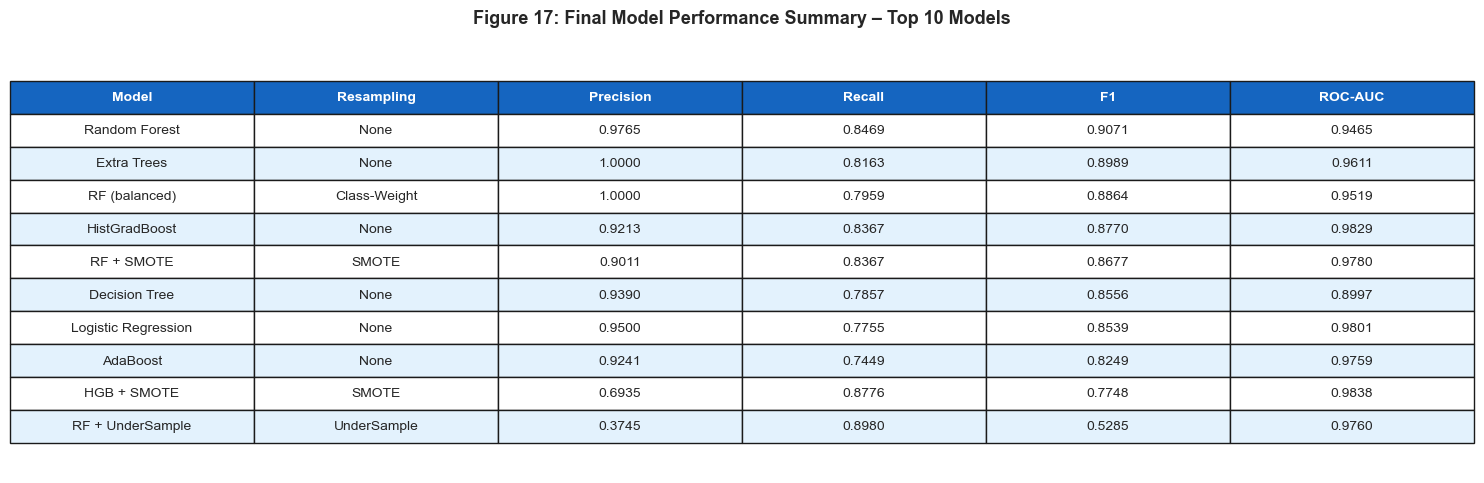

  [452.1s]  [saved] outputs/fig17_results_summary_table.png


In [23]:
 # FIGURE 17 – RESULTS SUMMARY TABLE


# Save CSV
df_export = df_res[["Model","Resampling","Accuracy","Precision",
                     "Recall","F1","ROC-AUC","PR-AUC","Time_s"]].copy()
for col in ["Accuracy","Precision","Recall","F1","ROC-AUC","PR-AUC"]:
    df_export[col] = df_export[col].map(
        lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
csv_path = os.path.join(OUT, "model_results_summary.csv")
df_export.to_csv(csv_path, index=False)
tick(f"CSV saved: {csv_path}")

# Summary table image
fig, ax = plt.subplots(figsize=(15, 5)); ax.axis("off")
td  = df_res.head(10)[["Model","Resampling","Precision","Recall","F1","ROC-AUC"]].values
fd  = [[r[0], r[1], f"{r[2]:.4f}", f"{r[3]:.4f}", f"{r[4]:.4f}",
        f"{r[5]:.4f}" if not __import__("math").isnan(r[5]) else "N/A"] for r in td]
tbl = ax.table(cellText=fd,
               colLabels=["Model","Resampling","Precision","Recall","F1","ROC-AUC"],
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1565C0")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#E3F2FD")
ax.set_title("Figure 17: Final Model Performance Summary – Top 10 Models",
             fontsize=13, fontweight="bold", pad=20)
fig.tight_layout()
savefig(fig, "fig17_results_summary_table.png")

In [24]:
 # FINAL SUMMARY PRINTOUT


total_time = time.time() - T0
best_row   = df_res.iloc[0]

print("\n" + "="*65)
print("  FINAL RESULTS SUMMARY")
print("="*65)
print()
print(df_res[["Model","Resampling","Precision",
              "Recall","F1","ROC-AUC","PR-AUC"]].to_string(index=False))
print()
print(f"  Best model by F1-Score  →  {best_row['Model']}")
print(f"    Precision  : {best_row['Precision']:.4f}")
print(f"    Recall     : {best_row['Recall']:.4f}")
print(f"    F1-Score   : {best_row['F1']:.4f}")
print(f"    ROC-AUC    : {best_row['ROC-AUC']:.4f}")
print(f"    PR-AUC     : {best_row['PR-AUC']:.4f}")
print(f"    Resampling : {best_row['Resampling']}")
print()
print(f"  Total runtime : {total_time:.1f} seconds")
print()
print("  Output files saved:")
for f in sorted(os.listdir(OUT)):
    print(f"    \u2022  {f}")
print()
print("  \u2714  All done.")
print("="*65)

# ── Download outputs as zip (Google Colab only) ───────────────────
try:
    import shutil
    from google.colab import files
    shutil.make_archive("outputs", "zip", "outputs")
    files.download("outputs.zip")
    print("\n  ✅ outputs.zip downloaded to your computer!")
except ImportError:
    import shutil
    shutil.make_archive("outputs", "zip", "outputs")
    print(f"     Location: {os.path.abspath('outputs.zip')}")


  FINAL RESULTS SUMMARY

              Model   Resampling  Precision   Recall       F1  ROC-AUC   PR-AUC
      Random Forest         None   0.976471 0.846939 0.907104 0.946476 0.875317
        Extra Trees         None   1.000000 0.816327 0.898876 0.961080 0.885352
      RF (balanced) Class-Weight   1.000000 0.795918 0.886364 0.951897 0.876119
      HistGradBoost         None   0.921348 0.836735 0.877005 0.982944 0.904656
         RF + SMOTE        SMOTE   0.901099 0.836735 0.867725 0.977959 0.886720
      Decision Tree         None   0.939024 0.785714 0.855556 0.899661 0.773295
Logistic Regression         None   0.950000 0.775510 0.853933 0.980075 0.862588
           AdaBoost         None   0.924051 0.744898 0.824859 0.975937 0.833202
        HGB + SMOTE        SMOTE   0.693548 0.877551 0.774775 0.983842 0.891953
   RF + UnderSample  UnderSample   0.374468 0.897959 0.528529 0.976048 0.842906
  HGB + UnderSample  UnderSample   0.339844 0.887755 0.491525 0.985751 0.856733
      LR (bala